# Detailed Explanation of Ridge (L2 Regularization)


## What is Ridge (L2 Regularization)?

Ridge regularization adds an **L2 penalty** to the loss function:

$$
Loss = OriginalLoss + \lambda \sum w^2
$$

In Logistic Regression:

$$
L = -\text{Log Likelihood} + \lambda ||w||^2
$$

It penalizes **large weights**, preventing overfitting.


## When to Use Ridge (L2)?

Use Ridge when:

* You have **multicollinearity**
* Number of features is large
* You want to reduce overfitting
* You believe most features contribute (not sparse)
* You prefer coefficient shrinkage instead of elimination


## Advantages

* Reduces overfitting
* Handles multicollinearity well
* Keeps all features (no zeroing)
* Stable and convex optimization
* Works well for high-dimensional data


## Disadvantages

* Does NOT perform feature selection (unlike L1/Lasso)
* Interpretation harder due to shrinkage
* Sensitive to feature scaling


## Important Hyperparameters

### C (Inverse of Regularization Strength)

In sklearn:

$$
C = \frac{1}{\lambda}
$$

* Small C → Strong regularization
* Large C → Weak regularization


### Solver

* `liblinear` → Small datasets
* `lbfgs` → Larger datasets
* `saga` → Large & sparse datasets


### max_iter

Increase if convergence warning appears.


## Practical Tuning Tips

1. Always scale features.
2. Tune C on log scale (e.g., logspace).
3. Use ROC-AUC for imbalanced data.
4. Use StratifiedKFold for classification.
5. Monitor learning curve:

   * High train, low val → Overfitting
   * Both low → Underfitting




**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Visualization settings
sns.set(style="whitegrid")

**Load dataset**

In [2]:
data = load_breast_cancer()

In [3]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [4]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
y.head()

0    0
1    0
2    0
3    0
4    0
dtype: int64

In [6]:
print("Dataset shape:", X.shape)

Dataset shape: (569, 30)


In [7]:
print("Target distribution:\n", y.value_counts())

Target distribution:
 1    357
0    212
Name: count, dtype: int64


In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [9]:
# Check missing values
print("Missing values:\n", X.isnull().sum().sum())

Missing values:
 0


In [10]:
# Basic statistics
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


**Train-Test Split**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (455, 30), Test shape: (114, 30)


**Model Creation (Ridge Logistic Regression)**

In [13]:
# Pipeline: Scaling + Logistic Regression with L2 penalty
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l2', solver='liblinear', max_iter=5000))
])

**Hyperparameter Tuning with GridSearchCV**

In [14]:
param_grid = {
    'model__C': np.logspace(-4, 4, 20)
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Best Parameters: {'model__C': np.float64(0.08858667904100823)}
Best CV ROC-AUC: 0.9941176470588236


**Model Evaluation**

In [15]:
best_model = grid_search.best_estimator_

In [16]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

In [18]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1-score: 0.9861111111111112
ROC-AUC: 0.996031746031746


In [19]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**Confusion Matrix Visualization**

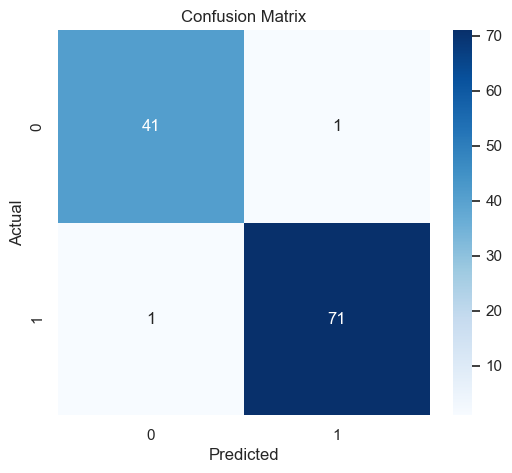

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve**

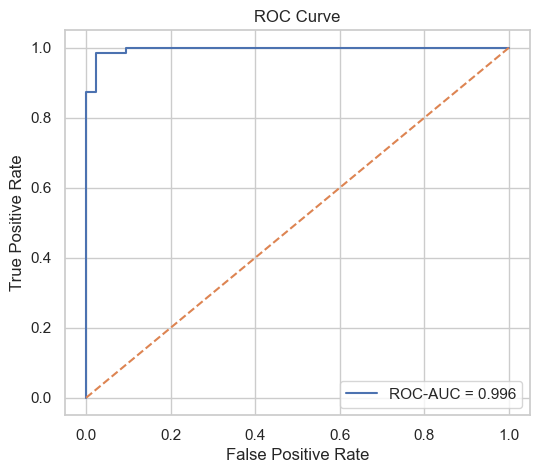

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Feature Importance (Coefficient Magnitude)**

In [22]:
# Extract coefficients
coefficients = best_model.named_steps['model'].coef_.ravel()
features = X.columns

# Create DataFrame
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
})

# Add absolute magnitude
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Sort
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

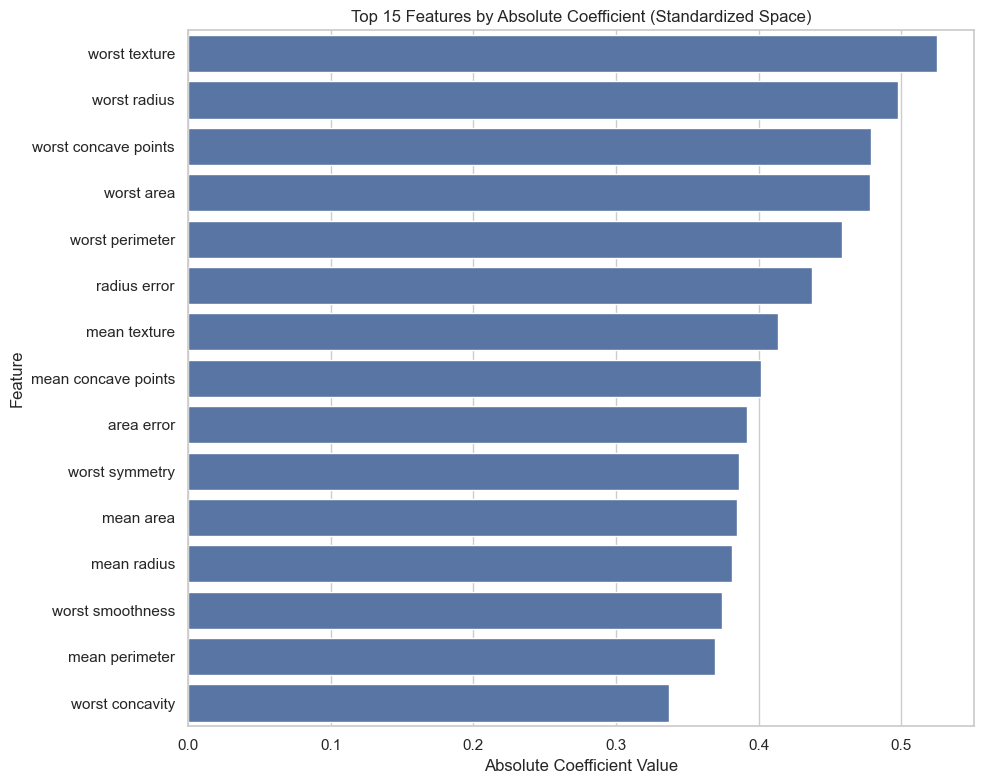

In [23]:
# Plot
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Abs_Coefficient',
    y='Feature',
    data=coef_df.head(15)
)

plt.title("Top 15 Features by Absolute Coefficient (Standardized Space)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Learning Curve**

In [24]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

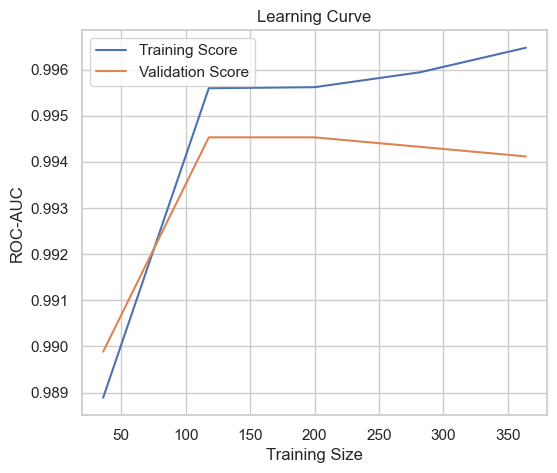

In [25]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(6,5))
plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, val_mean, label='Validation Score')
plt.xlabel("Training Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.legend()
plt.show()